# LLM in action: build a graph from a prompt, then ask it questions

The first two tutorials built a graph by hand and moved it between formats. This one hands both
jobs to a language model: **describe a building in English and get a valid BTwin graph back**, then
**ask questions in English and get answers out of SPARQL you never wrote**.

The interesting part is not that a model can emit JSON. It is the scaffolding around it — BTwin
hands the model a vocabulary, validates what comes back against that vocabulary, and sends failures
back for repair. The model is never trusted to know Brick or BOT.

**Prerequisites**

```bash
pip install "btwin[llm,rdf,viz]"
export OPENROUTER_API_KEY=sk-or-...
```

Without a key, `LLM.Constructor()` raises `ValueError`. The default model is
`google/gemini-2.5-flash-lite`; override it with `$OPENROUTER_MODEL` or the `model` argument.

**Two things to expect**

- **This costs money.** Not much — a full run of this notebook is well under a cent on the default
  model — but every cell that calls out is billed to your key. `CostMeter` tracks it, and the last
  section prints the total.
- **The outputs below will not reproduce exactly.** Even at `temperature=0.0` the model may answer
  differently on your run. Where it matters, this notebook *checks* the model's work rather than
  trusting it.

In [1]:
from pathlib import Path
import json

import btwin
from btwin import LLM, Tool, Cycle, CostMeter, NetworkX, RDF, GraphPlot

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

BASE = "https://example.org/santachiara/"

llm = LLM.Constructor()
meter = CostMeter()

print("BTwin", btwin.__version__)
print("model:", llm.model_name)

C:\Users\massa\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Couldn't import dot_parser, loading of dot files will not be possible.


BTwin 0.5.3
model: google/gemini-2.5-flash-lite


## 1. What the model is actually given

Before any prompt, BTwin builds two blocks of grounding text. This is the whole trick: the model is
not asked to *recall* Brick or BOT, it is *handed* them and told to use nothing else.

In [2]:
vocabulary = Tool.JSONLDVocabulary()

print("vocabulary sections:", list(vocabulary.keys()))
print("classes       :", len(vocabulary["classes"]))
print("properties    :", len(vocabulary["properties"]))
print("legal pairs   :", len(vocabulary["pairs"]))

vocabulary sections: ['prefixes', 'classes', 'properties', 'pairs']
classes       : 44
properties    : 19
legal pairs   : 10


In [3]:
vocabularyText = Tool.JSONLDVocabularyBlock(vocabulary)

print(f"{len(vocabularyText)} characters of vocabulary. First part:")
print()
print(vocabularyText[:700])

6248 characters of vocabulary. First part:

PREFIXES
  bot: https://w3id.org/bot#
  brick: https://brickschema.org/schema/Brick#
  btwin: btwin#
  eko: http://energy.linkeddata.es/em-kpi/ontology#
  ifc: https://standards.buildingsmart.org/IFC/DEV/IFC4/ADD2_TC1/OWL#
  kpi: http://bimerr.iot.linkeddata.es/def/key-performance-indicator#
  time: https://www.w3.org/TR/2022/CRD-owl-time-20221115#
  top: top#

CLASSES (allowed values of @type)
  bot:Building
  bot:Element
  bot:Interface
  bot:Site
  bot:Space
  bot:Storey
  bot:Zone
  brick:Air_Flow_Sensor
  brick:Air_Handling_Unit
  brick:Building
  brick:CO2_Sensor
  brick:Current_Sensor
  brick:Electric_Boiler
  brick:Energy_Zone
  brick:Equipment
  brick:Fan_Coil_Unit
  brick:Fire_Zone


`pairs` is the part that does the heavy lifting for correctness: it enumerates which
*subject type -> relationship -> object type* combinations are legal, so "a sensor is located in a
space" is allowed while "a building is located in a sensor" is not.

In [4]:
# A few legal combinations, as the model sees them
for pair in list(vocabulary["pairs"])[:8]:
    print("   ", pair)

    brick:hasLocation
    brick:isFedBy
    bot:interfaceOf
    btwin:isAdjacentTo
    btwin:hasPassageTo
    btwin:isDocumentOf
    btwin:hasDocument
    kpi:relatedScenario


In [5]:
notationText = Tool.JSONLDNotationBlock()

print(notationText)

The document is a single JSON object with '@context' and '@graph'.
Every node carries '@id', '@type', 'name' and a 'relationships' dict.
Relationships are NOT top-level keys: they live inside 'relationships', and each
target repeats the '@id' and the '@type' of the node it points at.

{
  "@context": {
    "brick": "https://brickschema.org/schema/Brick#",
    "bot": "https://w3id.org/bot#"
  },
  "@graph": [
    {
      "@id": "BLDG",
      "@type": "bot:Building",
      "relationships": {},
      "name": "Building"
    },
    {
      "@id": "BLDG-F1",
      "@type": "bot:Storey",
      "relationships": {
        "brick:hasLocation": [
          {
            "@id": "BLDG",
            "@type": "bot:Building"
          }
        ]
      },
      "name": "Floor 1"
    },
    {
      "@id": "BLDG-F1-S1",
      "@type": "bot:Space",
      "relationships": {
        "brick:hasLocation": [
          {
            "@id": "BLDG-F1",
            "@type": "bot:Storey"
          }
        ]
    

## 2. Build a graph from a prompt

`Cycle.JSONLDCreateByPrompt` runs a small pipeline:

1. **agent 1** writes a JSON-LD document, given the vocabulary, the notation and your prompt.
2. **agent 2** validates it — is it parseable, is every `@type` in the vocabulary, is every
   relationship a legal pair?
3. If validation fails, the error goes back to the model for repair, up to `maxRepairs` times.

`verbose=True` narrates each step.

In [6]:
PROMPT = '''
A two-storey outpatient clinic called Santa Chiara.
The ground floor has a waiting room and a consulting room.
The first floor has a laboratory and a small office.
Put a temperature sensor and a CO2 sensor in the waiting room,
a temperature sensor in the consulting room,
and a humidity sensor in the laboratory.
'''

created = Cycle.JSONLDCreateByPrompt(PROMPT, llm=llm, meter=meter, verbose=True)

clinic = created["jsonld"]

print()
print("validation passes needed:", created["attempts"])
print("nodes:", len(clinic["@graph"]))

[agent 1] 2849+1226 tokens, $0.000775
[agent 2] accepted after 1 pass(es), 11 nodes

validation passes needed: 1
nodes: 11


In [7]:
for obj in clinic["@graph"]:
    print(f"{obj['@id']:<24} {obj['@type']:<26} {obj.get('name','')}")
    for relationship, targets in (obj.get("relationships") or {}).items():
        for target in targets:
            print(f"{'':<24} {relationship} -> {target['@id']}")

SC-CLINIC                bot:Building               Santa Chiara Outpatient Clinic
SC-CLINIC-F0             bot:Storey                 Ground Floor
                         brick:hasLocation -> SC-CLINIC
SC-CLINIC-F1             bot:Storey                 First Floor
                         brick:hasLocation -> SC-CLINIC
SC-CLINIC-F0-WR          bot:Space                  Waiting Room
                         brick:hasLocation -> SC-CLINIC-F0
SC-CLINIC-F0-CR          bot:Space                  Consulting Room
                         brick:hasLocation -> SC-CLINIC-F0
SC-CLINIC-F1-LAB         bot:Space                  Laboratory
                         brick:hasLocation -> SC-CLINIC-F1
SC-CLINIC-F1-OFF         bot:Space                  Small Office
                         brick:hasLocation -> SC-CLINIC-F1
SC-CLINIC-F0-WR-TS1      brick:Temperature_Sensor   Temperature Sensor 1
                         brick:hasLocation -> SC-CLINIC-F0-WR
SC-CLINIC-F0-WR-CO2S1    brick:CO2_Sensor   

Nothing in that output was hand-written, and every `@type` is a real Brick or BOT class because the
validator would have rejected it otherwise.

Save it, so the rest of the notebook works on a fixed document:

In [8]:
(OUTPUT / "santa-chiara.json").write_text(
    json.dumps(clinic, indent=2, ensure_ascii=False), encoding="utf-8")

print("saved:", OUTPUT / "santa-chiara.json")

saved: output\santa-chiara.json


## 3. Check it with ordinary BTwin code

The graph is now just a BTwin document — no LLM involved from here on. Everything from the first
two tutorials applies.

In [9]:
G = NetworkX.ByJSONLD(clinic, printReport=False)

print(f"nodes: {G.number_of_nodes()}   edges: {G.number_of_edges()}")
print("isolated:", NetworkX.IsolatedNodes(G) or "none")

nodes: 11   edges: 10
isolated: none


Drawn graph with 11 nodes and 10 edges.


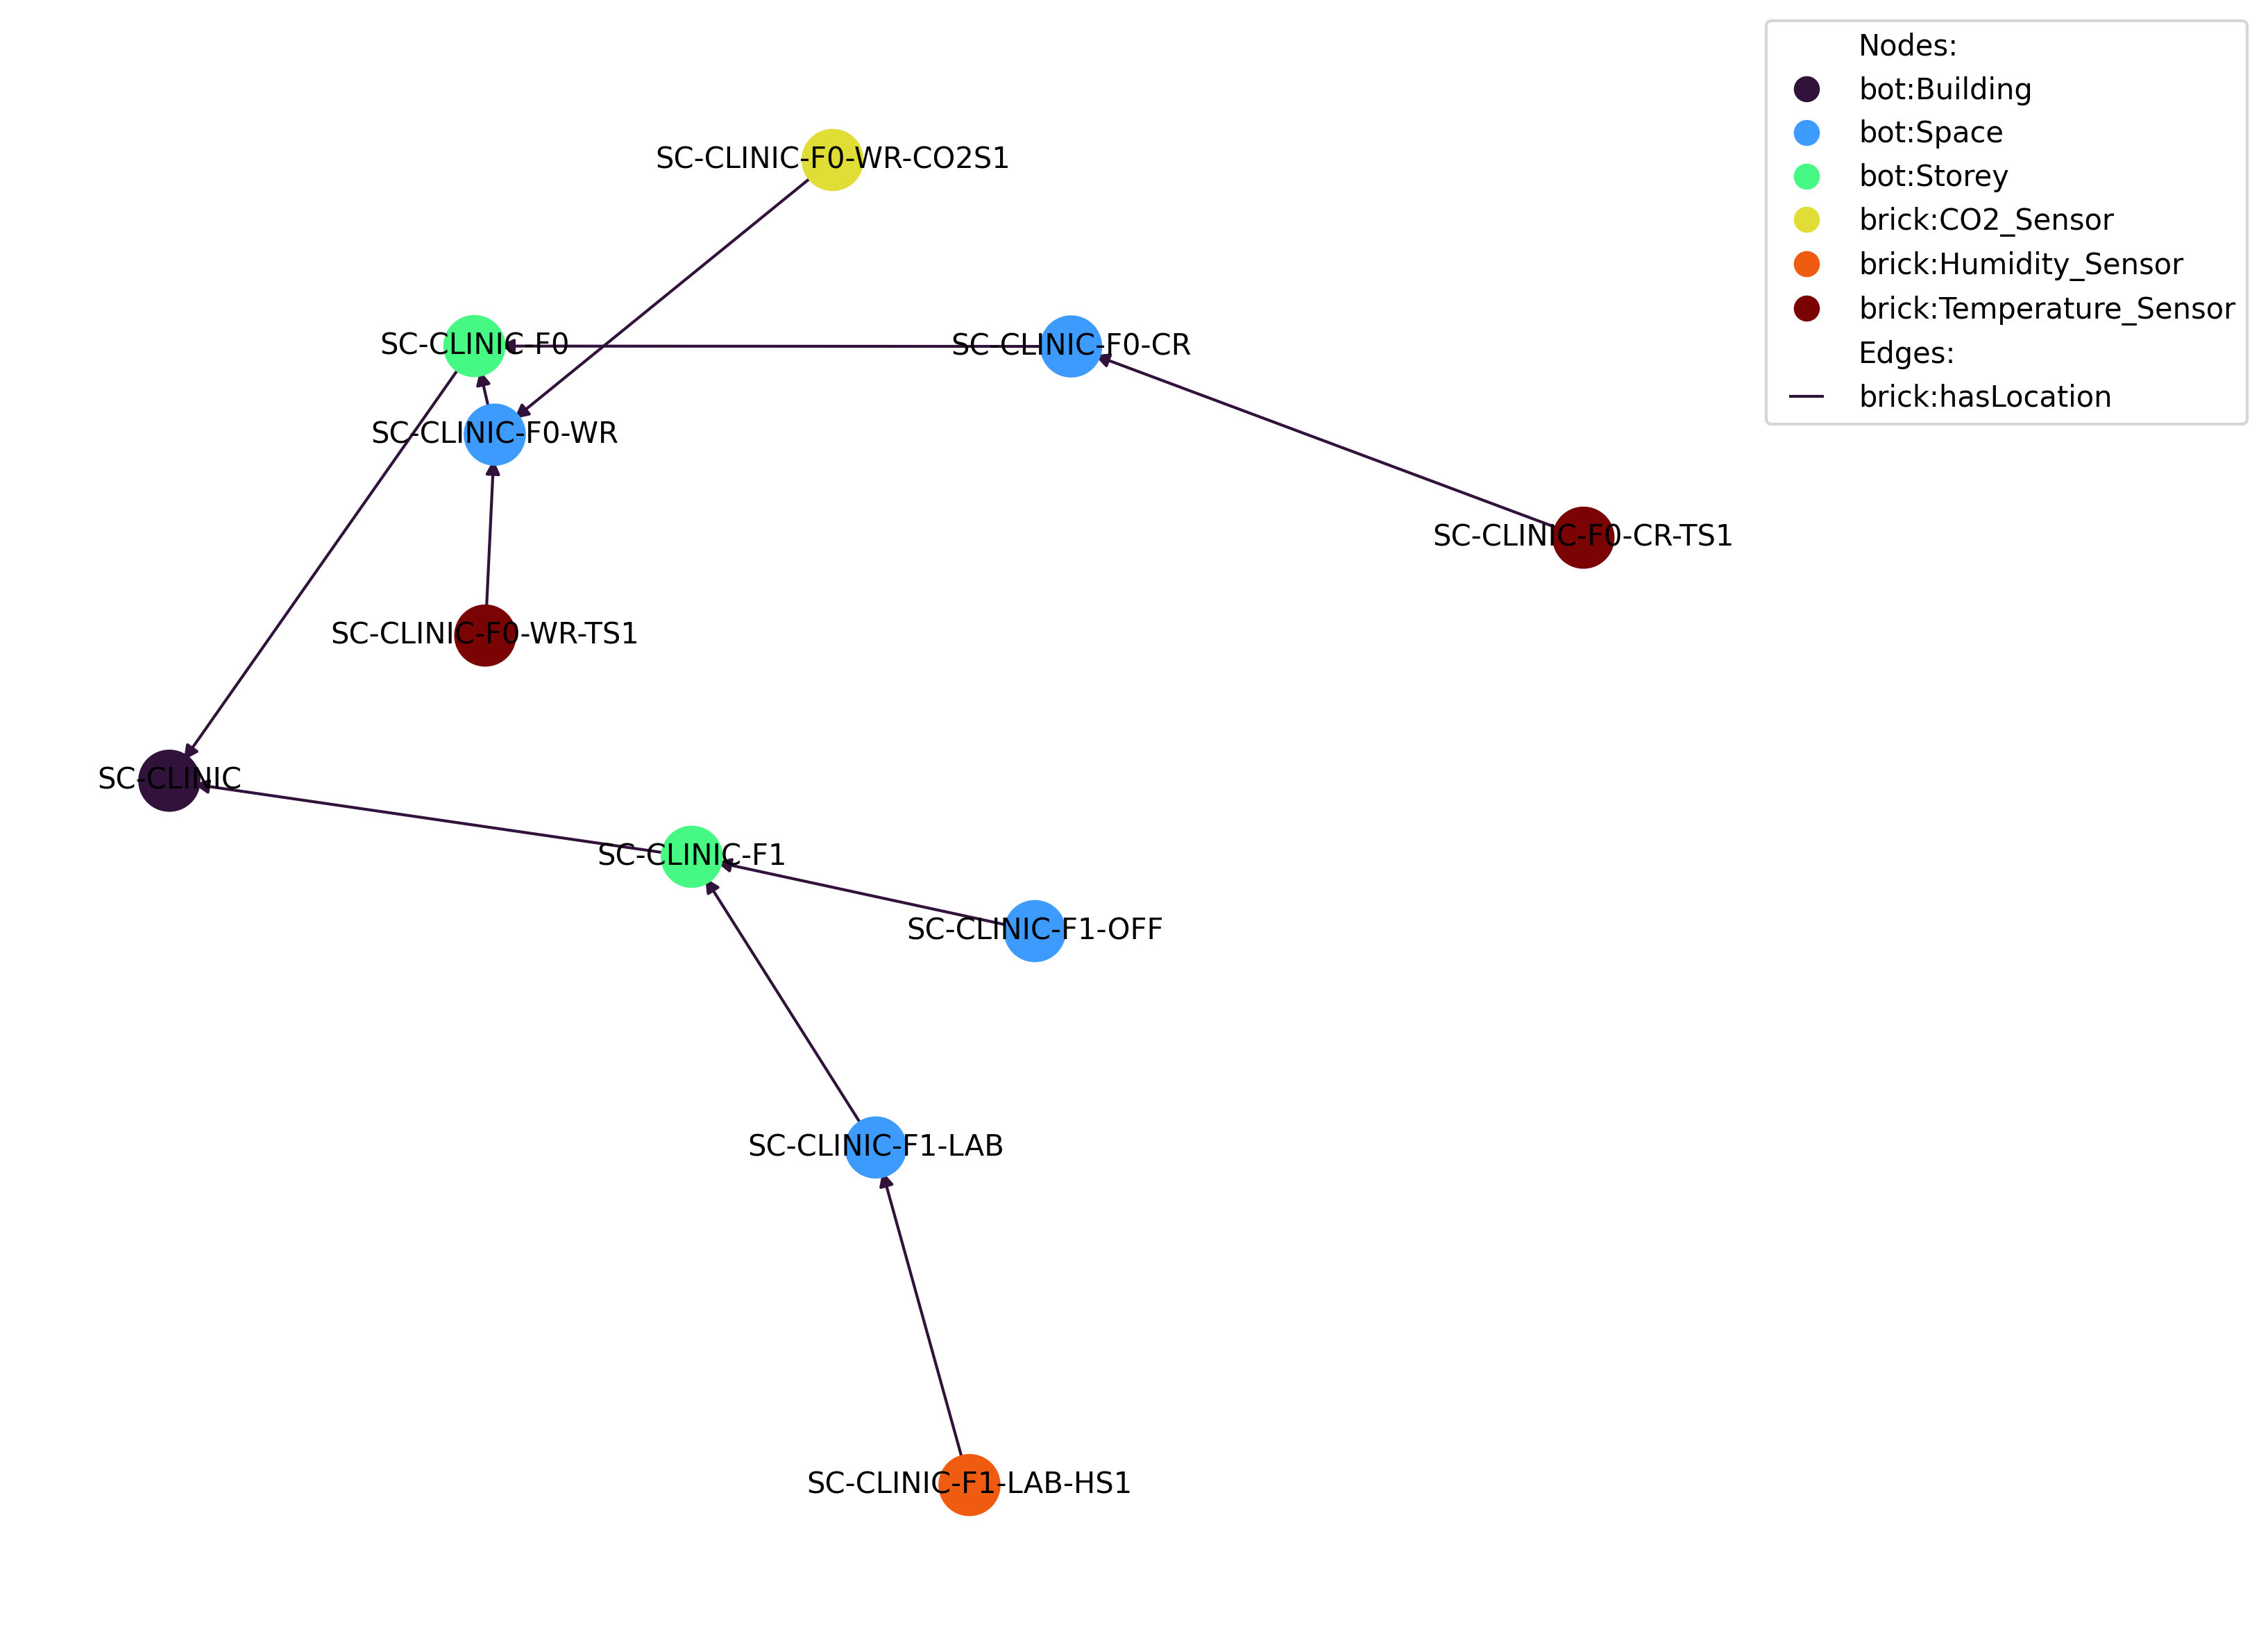

In [10]:
%matplotlib inline

fig, ax = GraphPlot.NetworkXByMatplotlib(
    G, nodeSize=420, figsize=(11, 8), layoutSeed=26,
    savePath=str(OUTPUT / "santa-chiara.png"))

## 4. Ask a question in English

`Cycle.RDFQueryByPrompt` is the mirror image of the create cycle:

1. **agent 3** writes SPARQL, grounded in a summary of *this* graph's actual classes and predicates.
2. **agent 4** validates the query — syntax, and every term against the vocabulary.
3. The query runs against rdflib.
4. **agent 5** turns the result rows into a sentence.

It needs an RDF graph, so convert first.

In [11]:
rdfGraph, turtle = RDF.ByJSONLD(
    clinic, savePath=OUTPUT / "santa-chiara.ttl", baseIRI=BASE, strict=False)

print("triples:", len(rdfGraph))

triples: 32


In [12]:
asked = Cycle.RDFQueryByPrompt(
    rdfGraph, "Which rooms have a CO2 sensor?", llm=llm, meter=meter, verbose=True)

print()
print("ANSWER:", asked["answer"])


[agent 3] 1025+151 tokens, $0.000163
[agent 3] proposed query:
PREFIX bot: <https://w3id.org/bot#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?roomLabel WHERE {
  ?sensor rdf:type brick:CO2_Sensor .
  ?sensor brick:hasLocation ?room .
  ?room rdf:type bot:Space .
  ?room rdfs:label ?roomLabel .
}
[agent 4] accepted
[agent 5] 1 row(s), no model call


[answer]  81+9 tokens, $0.000012

ANSWER: The Waiting Room has a CO2 sensor.


In [13]:
print("The SPARQL the model wrote:")
print()
print(asked["sparql"])
print("rows:", json.dumps(asked["rows"], default=str))

The SPARQL the model wrote:

PREFIX bot: <https://w3id.org/bot#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?roomLabel WHERE {
  ?sensor rdf:type brick:CO2_Sensor .
  ?sensor brick:hasLocation ?room .
  ?room rdf:type bot:Space .
  ?room rdfs:label ?roomLabel .
}
LIMIT 100
rows: [{"roomLabel": "Waiting Room"}]


## 5. Where this breaks: check the model's work

That question needed one hop — sensor to room. Now try one that needs two: sensor to room, room to
storey.

In [14]:
counted = Cycle.RDFQueryByPrompt(
    rdfGraph, "How many sensors are on the first floor?", llm=llm, meter=meter, verbose=True)

print()
print("ANSWER:", counted["answer"])
print()
print(counted["sparql"])


[agent 3] 1026+129 tokens, $0.000154
[agent 3] proposed query:
PREFIX bot: <https://w3id.org/bot#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT (COUNT(?sensor) AS ?sensorCount)
WHERE {
  <https://example.org/santachiara/SC-CLINIC-F1> brick:hasLocation ?space .
  ?sensor rdf:type brick:Sensor .
  ?sensor brick:hasLocation ?space .
}
[agent 4] rejected (1/4): Not in the schema: brick:Sensor. Use only the listed vocabulary.


[agent 4] 1114+169 tokens, $0.000179
[agent 4] repaired query:
PREFIX bot: <https://w3id.org/bot#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT (COUNT(?sensor) AS ?sensorCount)
WHERE {
  <https://example.org/santachiara/SC-CLINIC-F1> brick:hasLocation ?space .
  ?sensor rdf:type ?sensorType .
  ?sensorType rdfs:subClassOf* brick:Sensor .
  ?sensor brick:hasLocation ?space .
  VALUES ?sensorType { brick:CO2_Sensor brick:Humidity_Sensor brick:Temperature_Sensor }
}
[agent 4] rejected (2/4): Not in the schema: brick:Sensor. Use only the listed vocabulary.


[agent 4] 1154+153 tokens, $0.000177
[agent 4] repaired query:
PREFIX bot: <https://w3id.org/bot#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT (COUNT(?sensor) AS ?sensorCount)
WHERE {
  <https://example.org/santachiara/SC-CLINIC-F1> brick:hasLocation ?space .
  ?sensor rdf:type ?sensorType .
  ?sensor brick:hasLocation ?space .
  VALUES ?sensorType { brick:CO2_Sensor brick:Humidity_Sensor brick:Temperature_Sensor }
}
[agent 4] accepted
[agent 5] 1 row(s), no model call


[answer]  81+10 tokens, $0.000012

ANSWER: There are 0 sensors on the first floor.

PREFIX bot: <https://w3id.org/bot#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT (COUNT(?sensor) AS ?sensorCount)
WHERE {
  <https://example.org/santachiara/SC-CLINIC-F1> brick:hasLocation ?space .
  ?sensor rdf:type ?sensorType .
  ?sensor brick:hasLocation ?space .
  VALUES ?sensorType { brick:CO2_Sensor brick:Humidity_Sensor brick:Temperature_Sensor }
}
LIMIT 100


Now check it, instead of believing it. Here is the same question written by hand, walking the two
hops explicitly:

In [15]:
groundTruth = '''
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX rdfs:  <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?sensorName ?roomName WHERE {
  ?storey rdfs:label "First Floor" .
  ?room   brick:hasLocation ?storey ;
          rdfs:label ?roomName .
  ?sensor brick:hasLocation ?room ;
          rdfs:label ?sensorName .
}
'''

truth = RDF.Query(rdfGraph, groundTruth)

print("actually on the first floor:")
for row in truth:
    print(f"   {row['sensorName']} in {row['roomName']}")
print()
print(f"hand-written count : {len(truth)}")
print(f"model's answer     : {counted['answer']}")

actually on the first floor:
   Humidity Sensor 1 in Laboratory

hand-written count : 1
model's answer     : There are 0 sensors on the first floor.


Compare those two numbers. When they disagree, the cause is almost always **direction**:
`brick:hasLocation` runs from the contained thing to its container, so

```sparql
?storey brick:hasLocation ?room     # WRONG - asks what the storey is inside
?room   brick:hasLocation ?storey   # right - asks what is inside the storey
```

and a model that inverts it gets a query that is perfectly valid, passes every check BTwin
performs, returns zero rows, and produces the confident sentence "There are 0 sensors on the first
floor."

**This is the important lesson of the notebook.** The repair loop validates *syntax* and
*vocabulary*. Nothing validates *meaning*. An empty result set is not evidence of absence — it is
equally evidence of a backwards triple pattern.

Practical defences, in order of usefulness:

1. Read the generated SPARQL. `RDFQueryByPrompt` returns it in `["sparql"]` precisely so you can.
2. Treat zero rows as suspicious, not as an answer. `emptyRetries` exists for this.
3. Keep hand-written queries for the questions that matter and let the model handle exploration.

## 6. Edit the graph by prompt

`Cycle.JSONLDEditByPrompt` does not regenerate the document. It asks the model for a **patch**,
validates the patch against the vocabulary, and applies it — so an edit cannot silently rewrite
parts of the graph you did not mention.

In [16]:
edited = Cycle.JSONLDEditByPrompt(
    clinic,
    "Add a pharmacy on the ground floor, with a temperature sensor in it.",
    llm=llm, meter=meter, verbose=True)

print()
print("changes:", json.dumps(edited["changes"], indent=2))
print("nodes:", len(clinic["@graph"]), "->", len(edited["jsonld"]["@graph"]))

[agent 1] 3134+217 tokens, $0.000400
[agent 2] accepted after 1 pass(es), 2 addNodes -> 13 nodes

changes: {
  "addNodes": 2,
  "removeNodes": 0,
  "addRelationships": 0,
  "removeRelationships": 0,
  "renameNodes": 0
}
nodes: 11 -> 13


In [17]:
before = {o["@id"] for o in clinic["@graph"]}

for obj in edited["jsonld"]["@graph"]:
    if obj["@id"] not in before:
        print(json.dumps(obj, indent=2))

{
  "@id": "SC-CLINIC-F0-PH1",
  "@type": "bot:Space",
  "name": "Pharmacy",
  "relationships": {
    "brick:hasLocation": [
      {
        "@id": "SC-CLINIC-F0",
        "@type": "bot:Storey"
      }
    ]
  }
}
{
  "@id": "SC-CLINIC-F0-PH1-TS1",
  "@type": "brick:Temperature_Sensor",
  "name": "Pharmacy Temperature Sensor",
  "relationships": {
    "brick:hasLocation": [
      {
        "@id": "SC-CLINIC-F0-PH1",
        "@type": "bot:Space"
      }
    ]
  }
}


The same idea at the RDF level: `Cycle.RDFEditByPrompt` asks for a SPARQL `UPDATE`, validates it,
applies it, and reports the triples that actually moved.

In [18]:
rdfEdited = Cycle.RDFEditByPrompt(
    rdfGraph,
    "Add a CO2 sensor called Lab CO2 in the Laboratory.",
    llm=llm, meter=meter, verbose=True)

print()
print("added:")
for triple in rdfEdited["added"]:
    print("   ", triple)
print("removed:", rdfEdited["removed"] or "nothing")
print(f"triples: {len(rdfGraph)} -> {len(rdfEdited['graph'])}")


[agent 3] 1605+141 tokens, $0.000217
[agent 3] proposed update:
PREFIX bot: <https://w3id.org/bot#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

INSERT DATA {
  <https://example.org/santachiara/SC-CLINIC-F1-LAB-CO2S1> a brick:CO2_Sensor ;
    rdfs:label "Lab CO2" ;
    brick:hasLocation <https://example.org/santachiara/SC-CLINIC-F1-LAB> .
}
[agent 4] accepted (pass 1)
[apply]   +3 / -0 triple(s)

added:
    ('https://example.org/santachiara/SC-CLINIC-F1-LAB-CO2S1', 'rdf:type', 'brick:CO2_Sensor')
    ('https://example.org/santachiara/SC-CLINIC-F1-LAB-CO2S1', 'rdfs:label', 'Lab CO2')
    ('https://example.org/santachiara/SC-CLINIC-F1-LAB-CO2S1', 'brick:hasLocation', 'https://example.org/santachiara/SC-CLINIC-F1-LAB')
removed: nothing
triples: 32 -> 35


## 7. What the repair loop can and cannot fix

Additions work well. Modifications are harder, and there is a specific failure worth seeing.

Asking for a **rename** tends to produce a `DELETE WHERE { ... }` followed by an
`INSERT DATA { ... }` — two SPARQL operations with no `;` between them, which is a syntax error.
The validator catches it correctly. The repair then fails for an unexpected reason: at
`temperature=0.0` the model returns a byte-identical query to the one just rejected, so every
retry burns a call and changes nothing.

In [19]:
try:
    Cycle.RDFEditByPrompt(
        rdfGraph, "Rename the Small Office to Records Room.",
        llm=llm, meter=meter, maxRepairs=1, verbose=True)
    print()
    print("It worked this time - the model varies.")
except Exception as exc:
    print()
    print(f"{type(exc).__name__}: {exc}")


[agent 3] 1600+166 tokens, $0.000226
[agent 3] proposed update:
PREFIX bot: <https://w3id.org/bot#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

DELETE WHERE {
  <https://example.org/santachiara/SC-CLINIC-F1-OFF> rdfs:label "Small Office" .
}
INSERT DATA {
  <https://example.org/santachiara/SC-CLINIC-F1-OFF> rdfs:label "Records Room" .
}
[agent 4] rejected (1/2): Syntax error: Expected end of text, found 'INSERT'  (at char 300), (line:9, col:1)


[agent 4] 1615+166 tokens, $0.000228
[agent 4] repaired update:
PREFIX bot: <https://w3id.org/bot#>
PREFIX brick: <https://brickschema.org/schema/Brick#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

DELETE WHERE {
  <https://example.org/santachiara/SC-CLINIC-F1-OFF> rdfs:label "Small Office" .
}
INSERT DATA {
  <https://example.org/santachiara/SC-CLINIC-F1-OFF> rdfs:label "Records Room" .
}
[agent 4] rejected (2/2): Syntax error: Expected end of text, found 'INSERT'  (at char 300), (line:9, col:1)

ValueError: No runnable update after 2 attempt(s). Last error: Syntax error: Expected end of text, found 'INSERT'  (at char 300), (line:9, col:1)


`maxRepairs=1` keeps that demonstration cheap; the default of 3 would repeat the identical call
four times over.

If you hit this, the fixes are to raise `temperature` a little so retries actually differ, or to
phrase the request as something expressible in one operation.

## 8. What it cost

`CostMeter` has been accumulating every call in this notebook.

In [20]:
total = meter.Total()

print(f"calls             : {total['calls']}")
print(f"prompt tokens     : {total['promptTokens']:,}")
print(f"completion tokens : {total['completionTokens']:,}")
print(f"cost              : {CostMeter.Format(total['cost'])}")
print(f"estimated?        : {total['estimated']}")

calls             : 11
prompt tokens     : 15,284
completion tokens : 2,537
cost              : $0.002543
estimated?        : False


In [21]:
print("per call:")
for entry in meter.calls:
    print("   ", CostMeter.Describe(entry))

per call:
    2849+1226 tokens, $0.000775
    1025+151 tokens, $0.000163
    81+9 tokens, $0.000012
    1026+129 tokens, $0.000154
    1114+169 tokens, $0.000179
    1154+153 tokens, $0.000177
    81+10 tokens, $0.000012
    3134+217 tokens, $0.000400
    1605+141 tokens, $0.000217
    1600+166 tokens, $0.000226
    1615+166 tokens, $0.000228


## Questions to try

1. **Make the two-hop question work.** Re-ask "how many sensors are on the first floor" with the
   direction spelled out — something like "rooms whose location is the first floor". Does naming
   the direction fix it? Does a stronger model fix it without help?
2. **Break the validator on purpose.** Prompt for something outside the vocabulary — "add a bicycle
   rack and a swimming pool" — and read what agent 2 rejects and how the repair responds.
3. **Compare models.** Run the create cycle with `LLM.Constructor(model="...")` on two models and
   compare `attempts` and `usage`. Does a more expensive model pay for itself in fewer repairs?
4. **Ask a question with no answer.** "Which rooms have a pressure sensor?" There are none. Does
   the model say so, or invent one?

## Where to go next

- [`create-a-btwin-graph.ipynb`](create-a-btwin-graph.ipynb) — the same graph built by hand.
- [`graph-formats.ipynb`](graph-formats.ipynb) — JSON-LD, NetworkX, RDF and Neo4j in detail.
- `Tool.DocumentCreateByPrompt` — read a real PDF and infer a document node with its property set.
- `Tool.RDFWriteSPARQL` and `Tool.RDFAnswer` — the individual agents, if you want to drive the
  pipeline yourself instead of using `Cycle`.